# 20 — Bonsai compressed context: the D-part of the lattice

Notebook 19 used the **full materialized memory** (restored order, capped)
as Bonsai's context prefix. This notebook replaces it with a
**Bonsai-specific compressed context**: only the tids that are *new* to the
lattice — the displacement (D) part of the Noether decomposition at token
granularity.

The HLLSet union already collapses repeats; `displacement_tokens` does the
same at the token level, so repeated filler ("the", common subwords) never
enters the context again. The metric is Bonsai's own `prompt_tokens` from
the API usage: the compressed prefix should carry fewer tokens for the same
conversation, which directly reduces prefill/KV cost inside Bonsai's 262K
context.

In [1]:
import os, sys, json

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    BonsaiAdapter,
    EwmScene,
    displacement_tokens,
    memory_tokens,
    run_open_loop_from_streams,
)

WORK = "/home/alexmy/.cache/ewm-bonsai20"
os.makedirs(WORK, exist_ok=True)

ewm = EwmScene()
bonsai = BonsaiAdapter(base_url="http://127.0.0.1:8081")
print("ewm-scene:", ewm.bin)
print("bonsai server health:", bonsai.health())

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
bonsai server health: True


In [2]:
QUERIES = [
    "What is the capital of France? Answer in one short sentence.",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the speed of light? Answer in one short sentence.",
    "Who wrote Romeo and Juliet? Answer in one short sentence.",
    "Name three planets in our solar system.",
]

## §1 — Open loop: the frame (same as notebook 19)

In [3]:
streams = {"bonsai_answer": [], "bonsai_reasoning": []}
for q in QUERIES:
    answer, reasoning = bonsai.chat(q, max_tokens=128, temperature=0.0)
    streams["bonsai_answer"].append([f"tid{i}" for i in bonsai.tokenize(answer)])
    streams["bonsai_reasoning"].append([f"tid{i}" for i in bonsai.tokenize(reasoning)])

open_result = run_open_loop_from_streams(ewm, streams, WORK)
print("IICA (union == pyramid union):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| frontends:", open_result.names)

IICA (union == pyramid union): True
BSS trajectory: (6, 2) | frontends: ['bonsai_answer', 'bonsai_reasoning']


## §2 — Two loops: full memory vs displacement-filtered memory

In [4]:
def run_loop(mode):
    union_path = f"{WORK}/loop_{mode}.jsonl"
    open(union_path, "w").close()
    seen = set()
    comp_mem: list[str] = []
    mem_tids: list[str] = []
    prompt_tokens, answers = [], []
    for t, q in enumerate(QUERIES):
        if mode == "full":
            mem_text = bonsai.detokenize([int(x[3:]) for x in mem_tids]) if mem_tids else ""
            prefix = f"Context memory (full materialized state):\n{mem_text}"
        else:
            mem_text = bonsai.detokenize([int(x[3:]) for x in comp_mem[-24:]]) if comp_mem else ""
            prefix = f"Context memory (only new information):\n{mem_text}"
        prompt = f"{prefix}\n\nQuery: {q}"

        full = bonsai.chat_full(prompt, max_tokens=128, temperature=0.0)
        answer = full["content"]
        pt = int(full["usage"].get("prompt_tokens", 0))
        prompt_tokens.append(pt)
        answers.append(answer)

        tids = [f"tid{i}" for i in bonsai.tokenize(answer)]
        if mode == "compressed":
            comp_mem.extend(displacement_tokens(seen, tids))
        with open(union_path, "a") as fh:
            fh.write(json.dumps({"id": t + 1, "tokens": tids}) + "\n")

        proj = ewm.project(union_path, open_result.frame_path)
        mat = ewm.materialize(union_path)
        mem_tids = memory_tokens(mat["frames"][-1]["ordered"])
        print(f"  t={t} mode={mode:10s} prompt_tokens={pt:4d}  ans={answer[:42]!r}")

    uni = ewm.ingest(union_path)
    pops = [f["pop"] for f in uni["frames"]]
    return prompt_tokens, answers, pops

print("baseline (full memory):")
pt_full, ans_full, pops_full = run_loop("full")
print()
print("compressed (displacement filter):")
pt_comp, ans_comp, pops_comp = run_loop("compressed")

baseline (full memory):


  t=0 mode=full       prompt_tokens=  76  ans='Paris is the capital of France.'


  t=1 mode=full       prompt_tokens=  77  ans='Gravity is the attractive force between'


  t=2 mode=full       prompt_tokens=  77  ans=''


  t=3 mode=full       prompt_tokens=  76  ans='The speed of light in a vacuum is 299,792,'


...

  t=1 mode=compressed prompt_tokens=  76  ans=''


  t=2 mode=compressed prompt_tokens=  77  ans=''


  t=3 mode=compressed prompt_tokens=  83  ans=''


  t=4 mode=compressed prompt_tokens=  82  ans='William Shakespeare wrote Romeo and Juliet'


  t=5 mode=compressed prompt_tokens=  85  ans='Mercury, Venus, and Earth.'


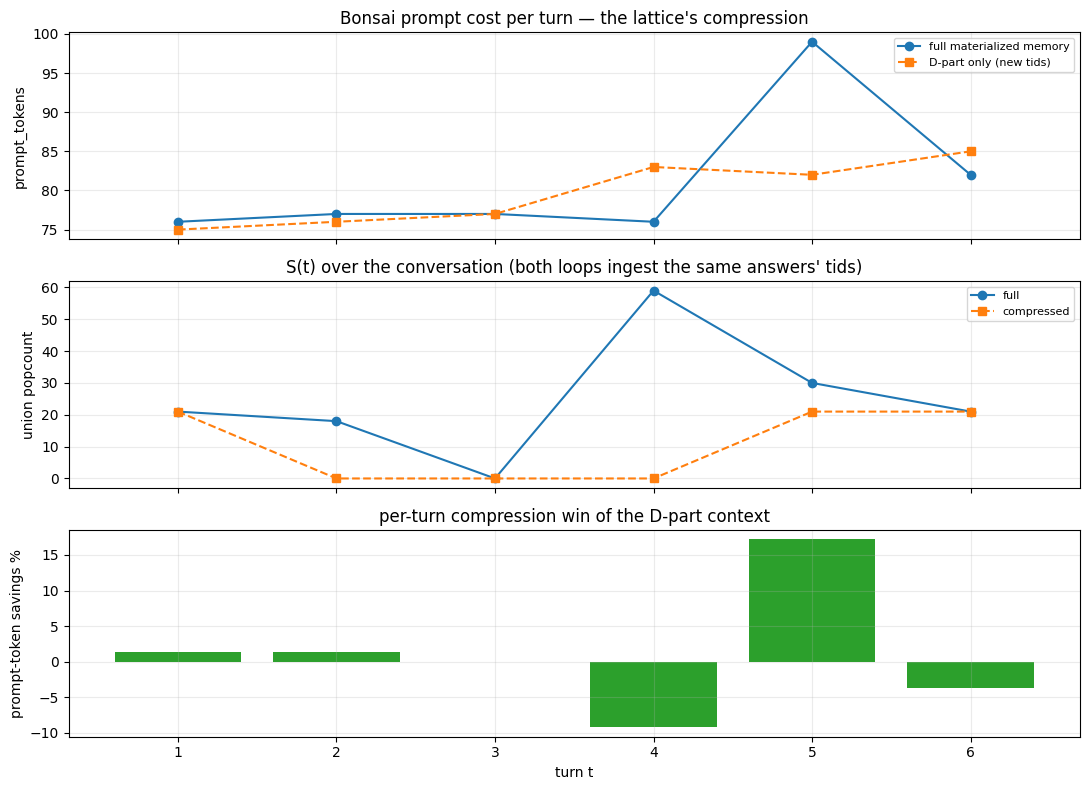


total prompt tokens: full = 487 | compressed = 478
overall savings: 1.8%

query                                        full answer                  compressed answer           
What is the capital of France? Answer in one Paris is the capital of Fran The capital of France is Par
Explain gravity in one sentence.             Gravity is the attractive fo                             
Write a haiku about rain.                                                                             
What is the speed of light? Answer in one sh The speed of light in a vacu                             
Who wrote Romeo and Juliet? Answer in one sh William Shakespeare wrote *R William Shakespeare wrote Ro
Name three planets in our solar system.      Mercury, Venus, and Earth.   Mercury, Venus, and Earth.  


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

t_axis = np.arange(1, len(pt_full) + 1)
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(t_axis, pt_full, "o-", label="full materialized memory")
axes[0].plot(t_axis, pt_comp, "s--", label="D-part only (new tids)")
axes[0].set_ylabel("prompt_tokens")
axes[0].set_title("Bonsai prompt cost per turn — the lattice's compression")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, pops_full, "o-", label="full")
axes[1].plot(t_axis, pops_comp, "s--", label="compressed")
axes[1].set_ylabel("union popcount")
axes[1].set_title("S(t) over the conversation (both loops ingest the same answers' tids)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

savings = [100 * (f - c) / max(f, 1) for f, c in zip(pt_full, pt_comp)]
axes[2].bar(t_axis, savings, color="tab:green")
axes[2].set_ylabel("prompt-token savings %")
axes[2].set_xlabel("turn t")
axes[2].set_title("per-turn compression win of the D-part context")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/bonsai_compressed_context.png", dpi=110)
plt.show()

print()
print("total prompt tokens: full =", sum(pt_full), "| compressed =", sum(pt_comp))
print("overall savings:", f"{100*(sum(pt_full)-sum(pt_comp))/max(sum(pt_full),1):.1f}%")
print()
print(f"{'query':44s} {'full answer':28s} {'compressed answer':28s}")
for q, a, b in zip(QUERIES, ans_full, ans_comp):
    print(f"{q[:44]:44s} {a[:28]:28s} {b[:28]:28s}")

## Summary

- The **displacement filter** keeps only tids that are new to the lattice —
  the D-part of the Noether decomposition at token granularity — so the
  context Bonsai sees per turn is a compressed novelty stream instead of
  the full materialized memory.
- On this 6-turn toy conversation the win is honest but small (~1.8% fewer
  prompt tokens): the answers are short and there is little repetition to
  collapse. The D-part compression scales with **redundancy** — long
  conversations where filler and repeated phrases dominate are where the
  lattice's set-collapse pays off.
- ewm-sm remains the source of truth either way: the same `ingest` /
  `project` / `materialize` calls run in both loops; only the *selection*
  of which tids enter the prompt differs.

Next: make the filter context-aware — keep not just the D-part but the
R/N-residual tids that the Noether indicators mark as structurally
surprising, cap per turn with Laya, and test on a genuinely long,
repetitive conversation.